
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms,
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project.


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence.

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter.

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string:
> `"headline [SEP] short_description"`.
>
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [56]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [57]:
# If needed (in a new env):
# !pip install -U datasets pillow

In [58]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets.


---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [59]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [60]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


#### **Print 10 random samples (combined text with separator, no truncation)**

In [61]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!).

In [62]:
# huff.save_to_disk("huffpost_splits")        # save
# from datasets import load_from_disk
# huff = load_from_disk("huffpost_splits")  # reload when needed

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


## Problem 1: HuffPost Exploratory Data Analysis

For this project, I selected the HuffPost News Category dataset.  
This section focuses on understanding the size, structure, balance, and quality of the dataset before moving into preprocessing and modeling later.

In [63]:
# ============================================================
# Problem 1: HuffPost EDA
# Label inspection
# ============================================================
# Confirm how many classes there are and what the
# category labels look like before building the EDA table.

# Make an encoded copy just to inspect the label vocabulary
huff_encoded = huff_all.class_encode_column("category")

label_names = huff_encoded.features["category"].names
num_classes = len(label_names)

print(f"Number of classes : {num_classes}")
print(f"First 5 labels    : {label_names[:5]}")
print(f"All labels        : {label_names}")

Number of classes : 41
First 5 labels    : ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE']
All labels        : ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']


In [41]:
# ============================================================
# Build a small working table for EDA
# ============================================================
# Turning the main text fields into a pandas DataFrame
# because it is easier to summarize, count, and plot.

# Keep the original string labels for readability in plots/tables
huff_df = pd.DataFrame({
    "category": huff_all["category"],
    "headline": huff_all["headline"],
    "short_description": huff_all["short_description"],
    "authors": huff_all["authors"],
    "date": huff_all["date"]
})

# Fill missing text so string operations do not fail
huff_df["headline"] = huff_df["headline"].fillna("").astype(str).str.strip()
huff_df["short_description"] = huff_df["short_description"].fillna("").astype(str).str.strip()

# Combine headline and description into one text field
# This follows the project instructions for the HuffPost dataset
huff_df["text"] = huff_df["headline"] + " [SEP] " + huff_df["short_description"]

print("Shape of working DataFrame:", huff_df.shape)
display(huff_df.head())

Shape of working DataFrame: (200853, 6)


,category,headline,short_description,authors,date,text
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26,There Were 2 Mass Shootings In Texas Last Week...
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26,Will Smith Joins Diplo And Nicky Jam For The 2...
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26,Hugh Grant Marries For The First Time At Age 5...
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26,Jim Carrey Blasts 'Castrato' Adam Schiff And D...
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26,Julianna Margulies Uses Donald Trump Poop Bags...


In [42]:
# ============================================================
# Basic dataset summary
# ============================================================

num_rows = len(huff_df)
num_classes = huff_df["category"].nunique()

print(f"Total rows        : {num_rows:,}")
print(f"Number of classes : {num_classes}")

print("\nRandom sample rows:")
display(huff_df.sample(5, random_state=42)[["category", "headline", "short_description"]])

Total rows        : 200,853
Number of classes : 41

Random sample rows:


,category,headline,short_description
56274,CRIME,Shooting Rampage Results In 'Mass Casualties' ...,"ORLANDO, Fla., June 12 (Reuters) - A gunman ki..."
9929,POLITICS,"Donald Trump Lashes Out At CNN, ABC Over Repor...","The president criticized the ""fake news media""..."
163271,STYLE & BEAUTY,Model Kate Moss Walks Louis Vuitton RTW Fall 2013,Golden girl model Kate Moss wowed in her usual...
190013,DIVORCE,7 Ways Single Moms Cope With Loneliness,“Am I the only single mom feeling lonely out t...
13564,POLITICS,Sen. Sherrod Brown: Steve Bannon 'Is A White S...,"Echoing comments by Rep. Frederica Wilson, he ..."


Top 10 largest categories:


,count
category,
POLITICS,32739
WELLNESS,17827
ENTERTAINMENT,16058
TRAVEL,9887
STYLE & BEAUTY,9649
PARENTING,8677
HEALTHY LIVING,6694
QUEER VOICES,6314
FOOD & DRINK,6226



Top 10 smallest categories:


,count
category,
MONEY,1707
ARTS,1509
FIFTY,1401
GOOD NEWS,1398
ARTS & CULTURE,1339
ENVIRONMENT,1323
COLLEGE,1144
LATINO VOICES,1129
CULTURE & ARTS,1030



Class balance summary
Largest class size : 32,739
Median class size  : 3,405
Smallest class size: 1,004
Max / median ratio : 9.61


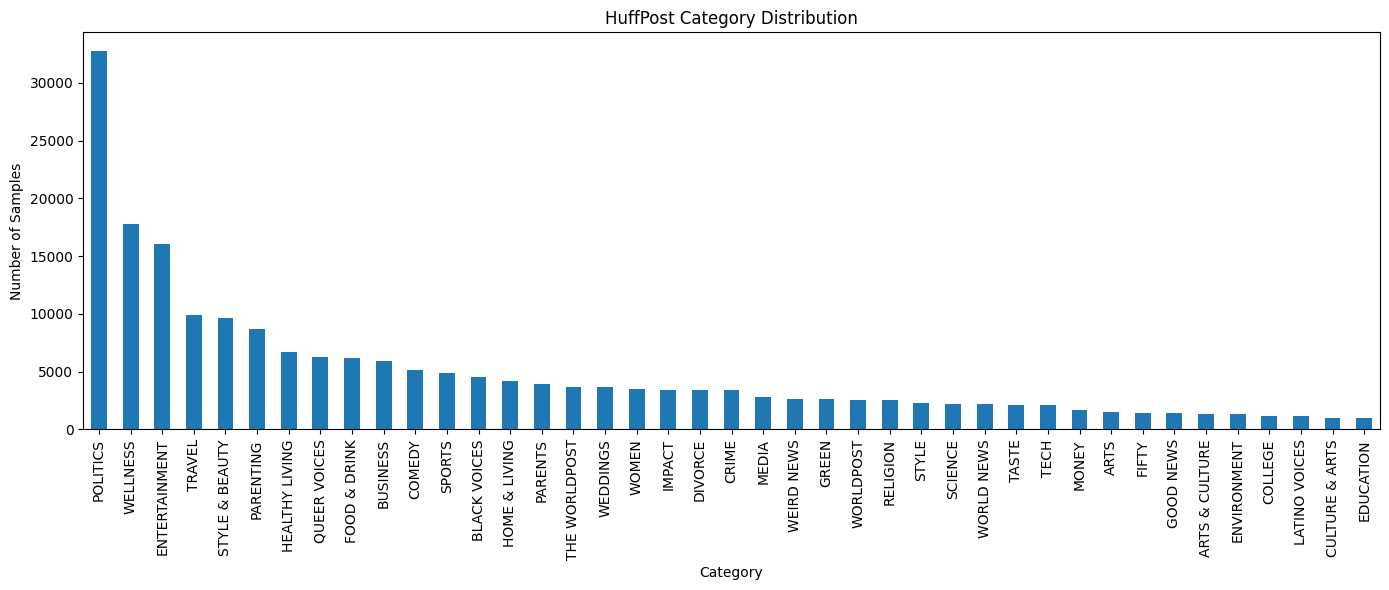

In [43]:
# ============================================================
# Class distribution
# ============================================================
# This checks whether some categories are much larger than others.

category_counts = huff_df["category"].value_counts().sort_values(ascending=False)

largest_class = category_counts.max()
smallest_class = category_counts.min()
median_class = category_counts.median()
imbalance_ratio = largest_class / median_class

print("Top 10 largest categories:")
display(category_counts.head(10))

print("\nTop 10 smallest categories:")
display(category_counts.tail(10))

print("\nClass balance summary")
print(f"Largest class size : {largest_class:,}")
print(f"Median class size  : {int(median_class):,}")
print(f"Smallest class size: {smallest_class:,}")
print(f"Max / median ratio : {imbalance_ratio:.2f}")

plt.figure(figsize=(14, 6))
category_counts.plot(kind="bar")
plt.title("HuffPost Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# Missing or weak text
# ============================================================
# To see some rows are missing useful information.

huff_df["headline_is_empty"] = huff_df["headline"].str.len() == 0
huff_df["description_is_empty"] = huff_df["short_description"].str.len() == 0
huff_df["both_empty"] = huff_df["headline_is_empty"] & huff_df["description_is_empty"]

# Word count helps identify very short examples
huff_df["word_count"] = huff_df["text"].str.split().str.len()

print("Empty text checks")
print(f"Empty headlines          : {huff_df['headline_is_empty'].sum():,}")
print(f"Empty short descriptions : {huff_df['description_is_empty'].sum():,}")
print(f"Both fields empty        : {huff_df['both_empty'].sum():,}")
print(f"Very short rows (<=5)    : {(huff_df['word_count'] <= 5).sum():,}")

display(
    huff_df.loc[huff_df["word_count"] <= 5, ["category", "headline", "short_description"]]
    .head(10)
)

Empty text checks
Empty headlines          : 6
Empty short descriptions : 19,712
Both fields empty        : 5
Very short rows (<=5)    : 981


,category,headline,short_description
12099,COMEDY,The Big Blue Wave,
22303,COMEDY,Trump's America,A limerick.
23764,POLITICS,Cuba Flee-bré,Get it?
25814,COMEDY,The Bechdel Test,
34710,TASTE,Bacardi: A Rum Story,
34712,BUSINESS,Pet Health Insurance,
34714,POLITICS,Health Care Reform,
35276,COMEDY,Constitutional Crossroads,
35278,FIFTY,"Love, Facebook and Infidelity",
37835,IMPACT,Home for Christmas,


In [45]:
# ============================================================
# Duplicate text check
# ============================================================
# Exact duplicates may indicate repeated stories or repeated rows.

duplicate_count = huff_df["text"].duplicated().sum()

print(f"Duplicate combined texts : {duplicate_count:,}")

if duplicate_count > 0:
    duplicate_examples = huff_df[huff_df["text"].duplicated(keep=False)][
        ["category", "headline", "short_description"]
    ].head(10)
    display(duplicate_examples)

Duplicate combined texts : 488


,category,headline,short_description
8966,PARENTS,The Funniest Tweets From Parents This Week,"Kids may say the darndest things, but parents ..."
9490,PARENTS,The Funniest Tweets From Parents This Week,"Kids may say the darndest things, but parents ..."
10300,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall F...",Spencer and Sally Hawkins play 1960s janitors ...
10335,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall F...",Spencer and Sally Hawkins play 1960s janitors ...
10363,MEDIA,"From Layoffs To Sexual Assault Allegations, It...","BuzzFeed, ESPN, ""Today"" and more hit new break..."
10371,ARTS & CULTURE,This New York Activist Wants To Replace A Stat...,Glenn Cantave believes white supremacy in 2017...
10384,STYLE,The Worst Beauty Trends Of 2017,"Bye-bye, glitter butts."
10390,POLITICS,Abortion Isn’t Main Reason More Republicans St...,Would the Democrats’ Alabama Senate candidate ...
10394,POLITICS,The 'Alt-Lite' White House Reporter Who Got Ar...,The former Proud Boy marched with white suprem...
10395,POLITICS,Abortion Isn’t Main Reason More Republicans St...,Would the Democrats’ Alabama Senate candidate ...


Word count summary:
count    200853.000000
mean         30.266852
std          14.046934
min           1.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: word_count, dtype: float64

Important word-count percentiles:
50th percentile: 29
75th percentile: 36
90th percentile: 50
95th percentile: 57
99th percentile: 68


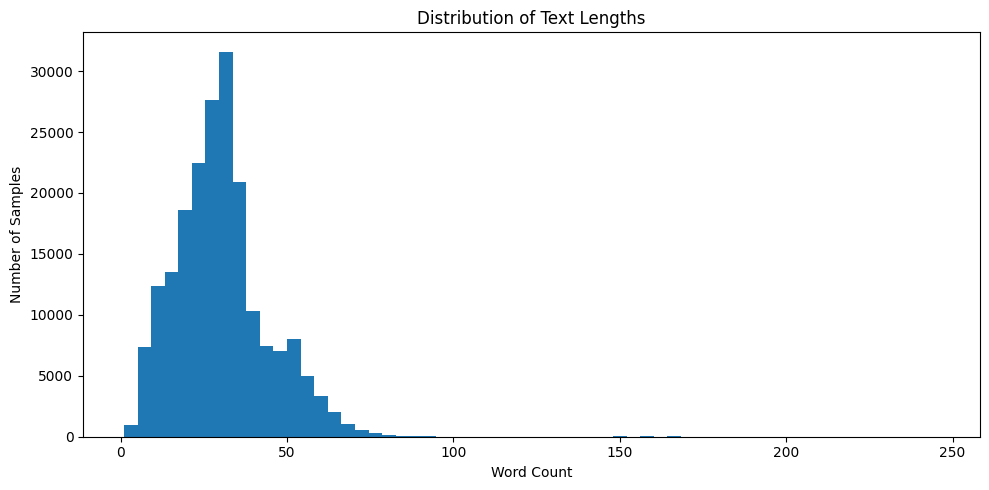

In [46]:
# ============================================================
# Text length analysis
# ============================================================
# This gives a better sense of how long the combined texts are.

huff_df["char_count"] = huff_df["text"].str.len()

print("Word count summary:")
print(huff_df["word_count"].describe())

print("\nImportant word-count percentiles:")
for p in [50, 75, 90, 95, 99]:
    value = np.percentile(huff_df["word_count"], p)
    print(f"{p}th percentile: {value:.0f}")

plt.figure(figsize=(10, 5))
plt.hist(huff_df["word_count"], bins=60)
plt.title("Distribution of Text Lengths")
plt.xlabel("Word Count")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# Candidate max lengths
# ============================================================
# This is still useful in Problem 1 because it helps show
# how much text-length variation there is.

candidate_lengths = [32, 64, 96, 128]

print("Estimated truncation rates")
for max_len in candidate_lengths:
    trunc_rate = (huff_df["word_count"] > max_len).mean() * 100
    print(f"max_text_length = {max_len:>3}: {trunc_rate:6.2f}% would be truncated")

Estimated truncation rates
max_text_length =  32:  36.68% would be truncated
max_text_length =  64:   1.60% would be truncated
max_text_length =  96:   0.11% would be truncated
max_text_length = 128:   0.08% would be truncated


In [48]:
# ============================================================
# Candidate max length for later planning
# ============================================================
# This is still useful in Problem 1 because it helps show
# how much text-length variation there is.

candidate_lengths = [32, 64, 96, 128, 256]

print("Estimated truncation rates")
for max_len in candidate_lengths:
    trunc_rate = (huff_df["word_count"] > max_len).mean() * 100
    print(f"max_text_length = {max_len:>3}: {trunc_rate:6.2f}% would be truncated")

Estimated truncation rates
max_text_length =  32:  36.68% would be truncated
max_text_length =  64:   1.60% would be truncated
max_text_length =  96:   0.11% would be truncated
max_text_length = 128:   0.08% would be truncated
max_text_length = 256:   0.00% would be truncated


In [49]:
# ============================================================
# Likely overlapping / ambiguous labels
# ============================================================
# These category pairs may be harder to separate because
# they cover similar topics and may use similar language.

overlap_pairs = [
    ("ARTS", "ARTS & CULTURE"),
    ("ARTS & CULTURE", "CULTURE & ARTS"),
    ("THE WORLDPOST", "WORLDPOST"),
    ("WORLDPOST", "WORLD NEWS"),
    ("PARENTS", "PARENTING"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("STYLE", "STYLE & BEAUTY"),
    ("TASTE", "FOOD & DRINK")
]

print("Likely overlapping category pairs:")
for left_cat, right_cat in overlap_pairs:
    if left_cat in huff_df["category"].unique() and right_cat in huff_df["category"].unique():
        print(f"- {left_cat} vs {right_cat}")

print("\nSample examples from overlapping pairs:")
for left_cat, right_cat in overlap_pairs:
    if left_cat in huff_df["category"].unique() and right_cat in huff_df["category"].unique():
        print("\n" + "=" * 60)
        print(f"{left_cat} vs {right_cat}")
        print("=" * 60)

        print(f"\nSample from {left_cat}:")
        left_rows = huff_df[huff_df["category"] == left_cat][
            ["headline", "short_description"]
        ].sample(
            n=min(2, len(huff_df[huff_df["category"] == left_cat])),
            random_state=42
        )

        for _, row in left_rows.iterrows():
            print("Headline :", row["headline"])
            print("Summary  :", row["short_description"])
            print()

        print(f"Sample from {right_cat}:")
        right_rows = huff_df[huff_df["category"] == right_cat][
            ["headline", "short_description"]
        ].sample(
            n=min(2, len(huff_df[huff_df["category"] == right_cat])),
            random_state=42
        )

        for _, row in right_rows.iterrows():
            print("Headline :", row["headline"])
            print("Summary  :", row["short_description"])
            print()

Likely overlapping category pairs:
- ARTS vs ARTS & CULTURE
- ARTS & CULTURE vs CULTURE & ARTS
- THE WORLDPOST vs WORLDPOST
- WORLDPOST vs WORLD NEWS
- PARENTS vs PARENTING
- WELLNESS vs HEALTHY LIVING
- STYLE vs STYLE & BEAUTY
- TASTE vs FOOD & DRINK

Sample examples from overlapping pairs:

ARTS vs ARTS & CULTURE

Sample from ARTS:
Headline : Demiurge
Summary  : I have now and then heard artists likened to the demiurge - Plato's word for the divinity that made the cosmos. This never made a visceral impression on me until I saw how Assael paints. He summons an image the way the Genesis demiurge summons the universe.

Headline : Why You Need Painting to Say That Painting Is Dead
Summary  : I'm a painter, so of course I find statements about the death of painting annoying, but also sloppy thinking, since painting is what it takes to be able to even make the statement.

Sample from ARTS & CULTURE:
Headline : St. Vincent's Sleek Ernie Ball Collaboration Is An 'Equal-Opportunity' Guitar
Su

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Dataset Summary**

 We selected the HuffPost News Category dataset for this project. This is a large text-based multiclass classification dataset containing 200,853 news records across 41 topic categories, including categories such as Politics, Entertainment, Parenting, Wellness, and World News. Each record contains a headline and a short description, which are combined into a single text input using the format headline [SEP] short_description. Our task is to predict which topic category a given article belongs to based on that text. In an applied setting, a model like this could support automatic article tagging, editorial workflow automation, recommendation systems, and content routing for digital news platforms.




2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Initial Observations**

Several findings stood out during the exploratory analysis. First, the dataset is clearly imbalanced: the largest class, Politics, contains 32,739 records, while the smallest class, Education, contains 1,004, which produces an imbalance ratio of about 9.61x relative to the median class size. Second, the text quality is uneven. We found 19,712 empty short descriptions, 6 empty headlines, 488 duplicate combined text records, and 981 very short examples with five words or fewer. Finally, some categories appear conceptually close or partially redundant, including pairs such as WorldPost and World News, Wellness and Healthy Living, and Style and Style & Beauty, which suggests that label overlap may be an important source of classification difficulty.
      



3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Challenges & Implications**

The main challenges likely to affect model performance are class imbalance, overlapping categories, duplicate records, and uneven text quality. If class imbalance is not handled carefully, the model may learn dominant categories more easily and underperform on smaller ones. Overlapping labels may also reduce accuracy because related stories often use similar language and cover similar subject matter. Missing or extremely short descriptions weaken the signal available to the model, while duplicates introduce a leakage risk if they are not removed before train, validation, and test splitting. In addition, the text-length distribution ranges from 1 word to 246 words, so sequence length will matter when the data are later prepared for a neural network.



4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Preparation Ideas**

To address these issues, we would first combine the headline and short description into a single text field so the model can use all available topic information. We would also remove duplicate texts before splitting the data to reduce leakage risk. Because the dataset is imbalanced, we would use a stratified train/validation/test split so that each split preserves the overall class proportions. The combined notebook also showed that most texts are fairly short, with a 95th percentile of 57 words and only 1.60% truncation at a maximum length of 64 words, so later preprocessing can choose a sequence length that preserves nearly all examples without making training unnecessarily expensive. We would also review whether extremely short records should be retained or filtered and consider class weighting if the model begins to over-favor the largest categories.




5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Reflection**

We chose HuffPost over Food-101 because it provides a richer and more realistic problem for this milestone. The dataset fits well with the course’s coverage of NLP, embeddings, and sequence modeling, and it also presents several real-world data challenges such as imbalance, duplicated records, missing descriptions, and overlapping labels. Compared with the image dataset, it is also more practical from a computational perspective, since it can be explored and modeled without depending as heavily on image preprocessing pipelines or GPU-intensive vision workflows. Overall, the dataset gives us a strong opportunity to practice text classification, data quality assessment, and multiclass evaluation in a setting that is both realistic and relevant to applied data science.




## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [50]:
# ============================================================
# Class imbalance summary
# ============================================================
# This checks whether some categories are much larger than others.
# That matters because a model may learn the biggest classes more
# easily and perform worse on minority categories.

category_counts = huff_df["category"].value_counts().sort_values(ascending=False)

largest_class = category_counts.max()
smallest_class = category_counts.min()
median_class = category_counts.median()
imbalance_ratio = largest_class / median_class

print("Class imbalance summary")
print(f"Largest class size : {largest_class:,}")
print(f"Median class size  : {int(median_class):,}")
print(f"Smallest class size: {smallest_class:,}")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}")

print("\nSmallest categories:")
display(category_counts.sort_values().head(10))

Class imbalance summary
Largest class size : 32,739
Median class size  : 3,405
Smallest class size: 1,004
Imbalance ratio    : 9.61

Smallest categories:


,count
category,
EDUCATION,1004
CULTURE & ARTS,1030
LATINO VOICES,1129
COLLEGE,1144
ENVIRONMENT,1323
ARTS & CULTURE,1339
GOOD NEWS,1398
FIFTY,1401
ARTS,1509


In [51]:
# ------------------------------------------------------------
# Text length patterns
# ------------------------------------------------------------
# This helps me understand how long the news texts usually are.
# Later, this will help me choose a reasonable max sequence length.

print("Word-count percentiles")
for p in [50, 75, 90, 95, 99]:
    value = np.percentile(huff_df["word_count"], p)
    print(f"{p}th percentile: {value:.0f}")

# Estimate how many examples would be cut off
# for a few possible sequence lengths.
candidate_lengths = [32, 64, 96, 128]

print("\nEstimated truncation rates")
for max_len in candidate_lengths:
    trunc_rate = (huff_df["word_count"] > max_len).mean() * 100
    print(f"max_text_length = {max_len:>3}: {trunc_rate:6.2f}% would be truncated")

Word-count percentiles
50th percentile: 29
75th percentile: 36
90th percentile: 50
95th percentile: 57
99th percentile: 68

Estimated truncation rates
max_text_length =  32:  36.68% would be truncated
max_text_length =  64:   1.60% would be truncated
max_text_length =  96:   0.11% would be truncated
max_text_length = 128:   0.08% would be truncated


In [52]:
# ------------------------------------------------------------
# Data quality checks
# ------------------------------------------------------------
# Here I am checking for weak or repeated examples that might
# affect training or evaluation later.

empty_headlines = (huff_df["headline"].str.len() == 0).sum()
empty_descriptions = (huff_df["short_description"].str.len() == 0).sum()
very_short_rows = (huff_df["word_count"] <= 5).sum()
duplicate_texts = huff_df["text"].duplicated().sum()

print("Data quality summary")
print(f"Empty headlines          : {empty_headlines:,}")
print(f"Empty short descriptions : {empty_descriptions:,}")
print(f"Very short rows (<=5)    : {very_short_rows:,}")
print(f"Duplicate combined texts : {duplicate_texts:,}")

Data quality summary
Empty headlines          : 6
Empty short descriptions : 19,712
Very short rows (<=5)    : 981
Duplicate combined texts : 488


In [53]:
# ============================================================
# Likely overlapping / ambiguous labels
# ============================================================
# These category pairs may be harder to separate because they
# cover closely related topics and may use similar language.

overlap_pairs = [
    ("ARTS", "ARTS & CULTURE"),
    ("ARTS & CULTURE", "CULTURE & ARTS"),
    ("THE WORLDPOST", "WORLDPOST"),
    ("WORLDPOST", "WORLD NEWS"),
    ("POLITICS", "WORLD NEWS"),
    ("PARENTS", "PARENTING"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("STYLE", "STYLE & BEAUTY"),
    ("TASTE", "FOOD & DRINK")
]

print("Likely overlapping category pairs:")
for left_cat, right_cat in overlap_pairs:
    if left_cat in huff_df["category"].unique() and right_cat in huff_df["category"].unique():
        print(f"- {left_cat} vs {right_cat}")

Likely overlapping category pairs:
- ARTS vs ARTS & CULTURE
- ARTS & CULTURE vs CULTURE & ARTS
- THE WORLDPOST vs WORLDPOST
- WORLDPOST vs WORLD NEWS
- POLITICS vs WORLD NEWS
- PARENTS vs PARENTING
- WELLNESS vs HEALTHY LIVING
- STYLE vs STYLE & BEAUTY
- TASTE vs FOOD & DRINK


In [54]:
# ============================================================
# Challenge-to-solution plan
# ============================================================
# This connects the EDA findings to practical next steps
# for Milestone 2.

solution_plan = pd.DataFrame({
    "Challenge": [
        "Class imbalance",
        "Variable text length",
        "Duplicates / leakage risk",
        "Empty or very short text",
        "Overlapping labels",
        "Compute constraints"
    ],
    "Planned approach": [
        "Use stratified train/validation/test splits and try class weights first",
        "Choose a practical max sequence length based on percentile results",
        "Deduplicate before splitting the data",
        "Keep headline-only rows initially but review whether very short rows should be filtered",
        "Inspect confusion patterns later and revisit closely related labels if needed",
        "Start with a moderate sequence length and batch size to keep training practical"
    ]
})

display(solution_plan)

,Challenge,Planned approach
0,Class imbalance,Use stratified train/validation/test splits an...
1,Variable text length,Choose a practical max sequence length based o...
2,Duplicates / leakage risk,Deduplicate before splitting the data
3,Empty or very short text,Keep headline-only rows initially but review w...
4,Overlapping labels,Inspect confusion patterns later and revisit c...
5,Compute constraints,Start with a moderate sequence length and batc...


In [55]:
# ============================================================
# Proposed Evaluation Protocol Summary

# ============================================================
# Define steps for model performance later.

print("Evaluation plan")
print("- Primary metric   : Macro-F1")
print("- Secondary metric : Accuracy")
print("- Also report      : Per-class precision, recall, and F1")
print("- Diagnostic tool  : Confusion matrix")
print("- Data split       : Stratified 70/15/15 with fixed seed = 42")
print("- Success meaning  : Strong baseline accuracy with a reasonable macro-F1 score,")
print("                     without large performance gaps between majority and minority classes")

Evaluation plan
- Primary metric   : Macro-F1
- Secondary metric : Accuracy
- Also report      : Per-class precision, recall, and F1
- Diagnostic tool  : Confusion matrix
- Data split       : Stratified 70/15/15 with fixed seed = 42
- Success meaning  : Strong baseline accuracy with a reasonable macro-F1 score,
                     without large performance gaps between majority and minority classes


### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **State the prediction task**

The prediction task is to classify each HuffPost news item into its correct topic category. Each example contains a headline and a short description, and the model must use that combined text to predict which one of the 41 news categories the article belongs to. This makes the project a multiclass text-classification problem, where the goal is to automatically assign a meaningful topic label to each article.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Define inputs and outputs**

The input to the model will be the combined article text, created by joining the headline and short description into one sequence using the format headline [SEP] short_description. For modeling, this text will be tokenized and converted into input IDs with attention masks, then padded or truncated to a fixed maximum length of 128 tokens. Since the dataset contains 41 categories, the model’s final output will be a prediction across those 41 classes.



3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Identify possible challenges**

Several challenges are likely to affect model performance on this dataset. First, the classes are clearly imbalanced: the largest category contains 32,739 records, while the smallest contains 1,004, which means a model may learn dominant categories more easily than minority ones. Second, the dataset contains 19,712 empty short descriptions, 981 very short examples, and 488 duplicate combined texts, all of which reduce data quality and increase the risk of leakage if duplicates are not handled before splitting. Third, some categories overlap conceptually, including pairs such as POLITICS and WORLD NEWS, WELLNESS and HEALTHY LIVING, and STYLE and STYLE & BEAUTY, which may cause the model to confuse related topics. Finally, the text lengths vary enough that sequence length must be chosen carefully so the model keeps most of the useful information without making training unnecessarily expensive.



4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size).

2.4. **Propose how I will prepare or improve the data to address the challenges**

To prepare the data, we would first combine the headline and short description into one text field and then check for empty, duplicate, or extremely short examples. We would use a stratified train, validation, and test split so that the class proportions stay similar across all splits. The text will be tokenized with a BERT-style tokenizer and padded or truncated to max_length=128, since EDA showed that this retains nearly the full dataset with minimal truncation. For text representation, we plan to begin with contextual embeddings from a pretrained BERT-base model, which uses a 768-dimensional hidden representation and should capture short news text more effectively than manual features alone. We will also use stratified 70/15/15 splits with a fixed random seed of 42 and apply class weighting during training to reduce bias toward large classes. If overlapping labels remain a major source of confusion, we will revisit possible label consolidation in Milestone 2.

5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—t5pically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Specify success metrics**

Because the HuffPost dataset is imbalanced, our primary evaluation metric will be macro-F1, since it gives equal weight to each class and provides a better view of performance across both large and small categories. We will also report overall accuracy as a secondary metric, although it will not be our main measure of success because it can be inflated by dominant classes such as Politics and Wellness. In addition, we will examine per-class precision, recall, and F1-score, along with a 41 × 41 confusion matrix, to identify where the model struggles most, especially among overlapping label groups. Performance will be evaluated using a stratified 70/15/15 train/validation/test split after deduplication, with a fixed random seed of 42. We will interpret success as achieving a solid baseline accuracy together with a reasonable macro-F1 score, without very large performance gaps between majority and minority categories.



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

We used generative AI minimally as a support tool to clarify a few concepts, improve the wording of some written responses, and organize parts of the notebook more clearly. We also used it occasionally to refine code comments and help troubleshoot when we became stuck. The dataset exploration, code execution, plots, and final modeling decisions were based on our own work using the provided notebook and data.



---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

